# EEG-GAN Analysis and Synthetic Data Generation

This notebook demonstrates the complete EEG-GAN pipeline for generating synthetic EEG data.

In [1]:
# =============================================================================
# PATH SETUP - Add src folder to Python path
# =============================================================================

import sys
from pathlib import Path

# Add project root and src folder to Python path
project_root = Path.cwd().parent
src_path = project_root / 'src' / 'eeg_synthetic'

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'✓ Added to Python path:')
print(f'  {src_path}')
print(f'  {project_root}')

✓ Added to Python path:
  /home/giorgio99/gan_bci/EEG-synthetic-main/EEG-synthetic-main/src/eeg_synthetic
  /home/giorgio99/gan_bci/EEG-synthetic-main/EEG-synthetic-main


# EEG-GAN Analysis and Synthetic Data Generation

This notebook demonstrates:
1. Loading and preprocessing EEG data
2. Training a Latent Autoencoder (LAE)
3. Training a GAN for synthetic EEG generation
4. Generating synthetic samples
5. Evaluating synthetic vs real data quality
6. Classification experiments


## Installation (First Time Only)

**IMPORTANT:** Before running this notebook, you need to install EEG-GAN:

```bash
# Option 1: Install from PyPI (recommended)
pip install eeggan --pre

# Option 2: Install from local eeggan_external folder
cd ../eeggan_external
pip install -e .
```

After installation, restart the Jupyter kernel before proceeding.

In [2]:
# =============================================================================
# CHECK EEGGAN INSTALLATION
# =============================================================================

try:
    import eeggan
    print(f'✓ EEG-GAN is installed (version: {eeggan.__version__ if hasattr(eeggan, "__version__") else "unknown"})')
except ImportError:
    print('✗ EEG-GAN is NOT installed')
    print('\\nPlease install it using one of these methods:')
    print('  1. pip install eeggan --pre')
    print('  2. cd ../eeggan_external && pip install -e .')
    print('\\nThen restart the kernel and run this cell again.')

✓ EEG-GAN is installed (version: unknown)


## 1. Setup and Data Loading

Import libraries and load the EEG dataset.

In [3]:
#Load other modules specific to this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random as rnd
from scipy import signal
from sklearn.preprocessing import scale
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

#Create a print formatting class
class printFormat:
    bold = '\033[1m'
    italic = '\033[3m'
    end = '\033[0m'

!eeggan setup_tutorial

eeggan_training_example.csv has been downloaded and saved to directory data.
eeggan_validation_example.csv has been downloaded and saved to directory data.
pretrained_autoencoder.pt has been downloaded and saved to directory trained_ae.
pretrained_gan.pt has been downloaded and saved to directory trained_models.
EEG-GAN tutorial files have been downloaded.


In [9]:
#Load the data
empiricalHeaders = np.genfromtxt('dataset_eeg_train_all_subj_all_sess.csv', delimiter=',', names=True).dtype.names
empiricalEEG = np.genfromtxt('dataset_eeg_train_all_subj_all_sess.csv', delimiter=',', skip_header=1)

#Print the head of the data
print(printFormat.bold + 'Display Header and first few rows/columns of data\n \033[0m' + printFormat.end)
print(pd.DataFrame(empiricalEEG, columns=empiricalHeaders).iloc[:5,:6])

#Print some information about the columns
print('\n' + '-'*90)
print(f"{printFormat.bold}\nNote the first four columns:{printFormat.end}\n"
      f"    ParticipantID - Indicates different participants\n"
      f"    Condition - Indicates the condition (WIN = 0, LOSE = 1) to be classified\n"
      f"    Trial - Indicates the trial number for that participant and condition\n"
      f"    Electrode - a numerical number ID of each electrode")
print('\nThe remaining columns are titled Time1 to Time100 - indicating 100 datapoints per sample.\n'
      'The samples span from -200 to 1000ms around the onset of a feedback stimulus.\n'
      'These are downsampled from the original data, which contained 600 datapoints per sample.')

# Print some meta-data
print('\n' + '-'*90)
print(f"\n{printFormat.bold}Other characteristics of our data include:{printFormat.end}")
print(f"-We have {len(set(empiricalEEG[:,0]))} participants in our training set")
average_trials = round(np.mean([np.max(empiricalEEG[empiricalEEG[:,0] == pID, 2]) for pID in set(empiricalEEG[:,0])]))
std_trials = round(np.std([np.max(empiricalEEG[empiricalEEG[:,0] == pID, 2]) for pID in set(empiricalEEG[:,0])]))
print(f"-Participants have an average of {average_trials} (SD: {std_trials}) trials per outcome (win, lose)")
print(f"-There are a total of {len(empiricalEEG)} samples in our data")
print(f"-There is {len(set(empiricalEEG[:,3]))} electrode in our data")


Display Header and first few rows/columns of data
 
   Condition  ParticipantID  SessionID  Trial  Electrode      Time1
0        0.0            1.0        1.0    1.0        1.0  14.987545
1        0.0            1.0        1.0    1.0        2.0  14.862270
2        0.0            1.0        1.0    1.0        3.0  10.674020
3        0.0            1.0        1.0    1.0        4.0  14.855703
4        0.0            1.0        1.0    1.0        5.0   8.487001

------------------------------------------------------------------------------------------

Note the first four columns:
    ParticipantID - Indicates different participants
    Condition - Indicates the condition (WIN = 0, LOSE = 1) to be classified
    Trial - Indicates the trial number for that participant and condition
    Electrode - a numerical number ID of each electrode

The remaining columns are titled Time1 to Time100 - indicating 100 datapoints per sample.
The samples span from -200 to 1000ms around the onset of a feedback

## 2. Data Preprocessing

Separate data by condition and prepare for training.

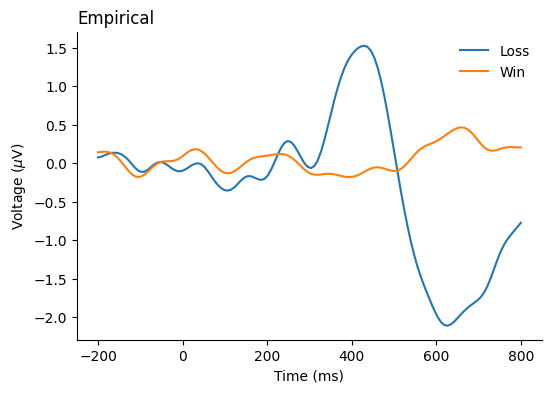

In [11]:
#Determine which rows are each condition (empiricalEEG[:,0] is the condition column, you can change it!)
lossIndex = np.where(empiricalEEG[:,0]==1.0)
winIndex = np.where(empiricalEEG[:,0]==0.0)

#Grand average the waveforms for each condition
lossWaveform = np.mean(empiricalEEG[lossIndex,-128:],axis=1)[0]
winWaveform = np.mean(empiricalEEG[winIndex,-128:],axis=1)[0]

#Determine x axis of time
time = np.linspace(-200,800,128)

#Setup figure
f, (ax1) = plt.subplots(1, 1, figsize=(6, 4))

#Plot each waveform
ax1.plot(time, lossWaveform, label = 'Loss')
ax1.plot(time, winWaveform, label = 'Win')

#Format plot
ax1.set_ylabel('Voltage ($\mu$V)')
ax1.set_xlabel('Time (ms)')
ax1.set_title('Empirical', loc='left')
ax1.spines[['right', 'top']].set_visible(False)
ax1.legend(frameon=False)

## 3. Latent Autoencoder (LAE) Training

Train the autoencoder to learn a compressed representation of EEG data.

In [ ]:
# Train Autoencoder Parameters
data = 'dataset_eeg_train_3_subj_3_sess.csv'
save_name = 'my_autoencoder_subj_3_sess_3.pt'
kw_channel = 'Electrode'
#kw_conditions = ['Condition','ParticipantID']
target = 'time'
time_out = 64
n_epochs = 2000
seed = 42

# Train the Autoencoder
!eeggan autoencoder_training \
    data={data} \
    save_name={save_name} \
    kw_channel={kw_channel} \
    kw_conditions=Condition \
    target={target} \
    time_out={time_out} \
    n_epochs=2000 \
    batch_size=64 \
    learning_rate=0.0001 \
    seed={seed}

#---------------------------------------------------------------------#
#---------------------------------------------------------------------#

# Alternatively, you could have written all parameters in place:
#!eeggan autoencoder_training data='data/eeggan_training_example.csv' save_name='test_ae.pt' kw_channel='Electrode' target='time' time_out=50 n_epochs=10 seed=42


-----------------------------------------
Command line arguments:
-----------------------------------------

Dataset: dataset_eeg_train_3_subj_3_sess.csv
Model save name: my_autoencoder_subj_3_sess_3_1.pt
Channel label: Electrode
Target: time
Encoded time series size: 64
Number of epochs: 2000
Batch size: 64
Learning rate: 0.0001
Manual seed: True
-----------------------------------------

AE Training BILANCIATO attivato (128 punti). Classi: [0 1]
  1%| | 29/2000 [00:06<07:14,  4.53it/s, TRAIN LOSS: 0.046012, TEST LOSS: 0.0356
Keyboard interrupt detected.
Cancel training and continue with further operations.
Managing checkpoints...
^C
Traceback (most recent call last):
  File "/home/giorgio99/miniconda3/envs/eeg_research/bin/eeggan", line 6, in <module>
    sys.exit(main())
             ^^^^^^
  File "/home/giorgio99/miniconda3/envs/eeg_research/lib/python3.11/site-packages/eeggan/__main__.py", line 36, in main
    autoencoder_training_main(args)
  File "/home/giorgio99/miniconda3/env

In [ ]:
!eeggan lae_training \
    data='dataset_eeg_train_3_subj_3_sess.csv' \
    autoencoder='trained_ae/my_autoencoder_subj_3_sess_3.pt' \
            kw_conditions=Condition \
    kw_channel='Electrode' \
    n_epochs=1000 \
    batch_size=64 \
    save_name='test_latent_ae_v1' \
    patch_size=16 \
            ae_lr=0.0001 \
    seed=42

## 4. GAN Training

Train the GAN using the pretrained autoencoder.

In [ ]:
# Se i tuoi dati sono nel file che abbiamo creato prima:

!eeggan gan_training \
    data='dataset_eeg_train_3_subj_3_sess.csv' \
    autoencoder='trained_ae/my_autoencoder_subj_3_sess_3.pt' \
    checkpoint='trained_models/test_latent_ae_v1.pt' \
    save_name='my_aegan_subj_3_sess_3.pt' \
    kw_conditions=Condition \
    kw_channel='Electrode' \
    patch_size=16 \
    n_epochs=2000 \
    batch_size=64 \
    generator_lr=0.0001 \
    discriminator_lr=0.0001 \
    seed=42
# Train the AE-GAN on GPUs
#!eeggan gan_training ddp data={data} autoencoder={autoencoder} save_name={save_name} kw_conditions={kw_conditions} kw_channel={kw_channel} patch_size={patch_size} n_epochs={n_epochs} seed={seed}
# Note, on Google Colab you can start a GPU runtime by going to Runtime > Change runtime type > Hardware accelerator > GPU

#---------------------------------------------------------------------#
#---------------------------------------------------------------------#

# Alternatively, you could have written all parameters in place:
#!eeggan gan_training data='data/eeggan_training_example.csv' autoencoder='trained_ae/test_ae.pt' save_name='demo_aegan.pt' kw_conditions='Condition' kw_channel='Electrode' patch_size=10 n_epochs=10 seed=42
#!eeggan gan_training data='data/eeggan_training_example.csv' ddp autoencoder='trained_ae/test_ae.pt' save_name='demo_aegan.pt' kw_conditions='Condition' kw_channel='Electrode' patch_size=10 n_epochs=10 seed=42


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wasserstein_distance # Libreria fondamentale per la metrica
from eeggan.helpers.dataloader import Dataloader
from eeggan.helpers.initialize_gan import init_gan

def standardize_signal(tensor):
    """Standardizza il segnale: (x - mean) / std lungo l'asse del tempo."""
    # Nota: manteniamo la tua logica di standardizzazione globale sul trial
    mean = tensor.mean()
    std = tensor.std()
    return (tensor - mean) / (std)

def visualize_class_reconstruction(checkpoint_path, data_path, target_class=1):
    # 1. Caricamento Checkpoint
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    opt = checkpoint['configuration']
    
    latent_dim = opt.get('latent_dim', 128)
    n_cond = opt.get('n_conditions', 1)
    n_channels = opt.get('n_channels', 8)
    opt['latent_dim_in'] = latent_dim + n_cond
    opt['channel_in_disc'] = n_channels + n_cond
    opt['device'] = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 2. Inizializzazione Modelli
    generator, discriminator = init_gan(**opt)
    
    key_gen = 'generator' if 'generator' in checkpoint else 'generator_state_dict'
    key_disc = 'discriminator' if 'discriminator' in checkpoint else 'discriminator_state_dict'
    generator.load_state_dict(checkpoint[key_gen])
    discriminator.load_state_dict(checkpoint[key_disc])
    
    generator.to(opt['device']).eval()
    discriminator.to(opt['device']).eval()
    discriminator.encode_input(True)
    generator.decode_output(True)

    # 3. Caricamento Dati
    dataloader = Dataloader(data_path, kw_time=opt['kw_time'], 
                            kw_conditions=opt['kw_conditions'], kw_channel=opt['kw_channel'])
    dataset = dataloader.get_data()
    labels_all = dataset[:, 0, 0].numpy()
    indices = np.where(np.round(labels_all) == target_class)[0]
    
    if len(indices) == 0: return
    
    sample_idx = indices[0]
    trial = dataset[sample_idx:sample_idx+1].to(opt['device']).float()
    real_labels = trial[:, :n_cond, 0].unsqueeze(1) 
    real_eeg_raw = trial[:, n_cond:, :]
    real_eeg = standardize_signal(real_eeg_raw)

    # 4. Pipeline di Ricostruzione
    with torch.no_grad():
        real_reduced = discriminator.encoder.encode(real_eeg)
        repeated_labels = real_labels.repeat(1, 1, real_reduced.shape[1]).permute(0, 2, 1)
        encoder_input = torch.cat((real_reduced, repeated_labels), dim=-1)
        
        base_disc = discriminator.discriminator if hasattr(discriminator, 'discriminator') else discriminator
        encoder_head = torch.nn.Sequential(
            base_disc[0], base_disc[1], base_disc[2].clshead[0], base_disc[2].clshead[1]
        ).to(opt['device'])
        z = encoder_head(encoder_input)
        
        cond = real_labels.view(1, -1)
        z_conditioned = torch.cat((z, cond), dim=-1)
        recon_reduced = generator.generator(z_conditioned)
        recon_full_raw = generator.decoder.decode(recon_reduced)
        recon_full = standardize_signal(recon_full_raw)

    # 5. CALCOLO DISTANZA DI WASSERSTEIN
    wasserstein_scores = []
    print(f"\n--- Metriche Wasserstein (Classe {target_class}) ---")
    
    for i in range(n_channels):
        r_np = real_eeg[0, :, i].cpu().numpy()
        s_np = recon_full[0, :, i].cpu().numpy()
        
        # Calcolo della distanza di Wasserstein 1D
        dist = wasserstein_distance(r_np, s_np)
        wasserstein_scores.append(dist)
        print(f"Canale {i}: {dist:.4f}")

    mean_wasserstein = np.mean(wasserstein_scores)
    print(f"DISTANZA MEDIA DI WASSERSTEIN: {mean_wasserstein:.4f}")

    # 6. Visualizzazione
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()
    
    for i in range(8):
        r_np = real_eeg[0, :, i].cpu().numpy()
        s_np = recon_full[0, :, i].cpu().numpy()
        
        axes[i].plot(r_np, label='Reale', color='royalblue', alpha=0.8)
        axes[i].plot(s_np, label='Ricostruito', color='crimson', linestyle='--')
        axes[i].set_title(f"Canale {i}\nW-Dist: {wasserstein_scores[i]:.4f}")
        axes[i].legend()
        axes[i].grid(True, alpha=0.2)

    plt.suptitle(f"Ricostruzione Latent AE - CLASSE {target_class}\nW-Dist Media: {mean_wasserstein:.4f}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Esecuzione
visualize_class_reconstruction(
    checkpoint_path='trained_models/test_latent_ae_v1.pt',
    data_path='dataset_eeg_test_3_subj_3_sess.csv',
    target_class=1
)

In [ ]:
import torch
import matplotlib.pyplot as plt

# Carica il modello
state_dict = torch.load('trained_models/my_aegan_subj_3_sess_3.pt', map_location='cpu')

plt.figure(figsize=(10, 5))

# Seguendo la logica di visualize_main.py: cerca tutte le chiavi che contengono "loss"
loss_found = False
for key in state_dict.keys():
    if 'loss' in key:
        plt.plot(state_dict[key], label=key, marker='.')
        loss_found = True

if loss_found:
    plt.title('Training Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Nessuna chiave 'loss' trovata nel file. Chiavi disponibili:", state_dict.keys())




## 5. Generate Synthetic EEG Samples

Use the trained GAN to generate synthetic EEG data.

In [ ]:
!eeggan generate_samples \
    model=trained_models/my_aegan_subj_3_sess_3.pt \
    conditions=0 \
    num_samples_total=1200\
    num_samples_parallel=20 \
    save_name=aegan_data_c0_subj_3_sess_3.csv \
    seed=42
!eeggan generate_samples \
        model=trained_models/my_aegan_subj_3_sess_3.pt \
        conditions=1 \
    num_samples_total=1200 \
    num_samples_parallel=20 \
    save_name=aegan_data_c1_subj_3_sess_3.csv \
    seed=42


In [ ]:

syntheticHeaders = np.genfromtxt('generated_samples/aegan_data_c0_subj_3_sess_3.csv', delimiter=',', names=True).dtype.names
gan_c0 = np.genfromtxt('generated_samples/aegan_data_c0_subj_3_sess_3.csv', delimiter=',', skip_header=1)
gan_c1 = np.genfromtxt('generated_samples/aegan_data_c1_subj_3_sess_3.csv', delimiter=',', skip_header=1)
syntheticEEG = np.concatenate((gan_c0,gan_c1),axis=0)

#Print head of the data
print(f"{printFormat.bold}Display first few rows/columns of data{printFormat.end}")
print(pd.DataFrame(syntheticEEG, columns=syntheticHeaders).iloc[:5,:6])

# Print condition sample counts
print(f"\n{printFormat.bold}Display trial counts for each condition{printFormat.end}")
print(f"{printFormat.bold}Win: {printFormat.end}{np.sum(syntheticEEG[:, 0] == 0)}")
print(f"{printFormat.bold}Lose: {printFormat.end}{np.sum(syntheticEEG[:, 0] == 1)}")

## 6. Visualization: Real vs Synthetic

Compare real and synthetic EEG signals visually.

In [ ]:
#Determine 5 random trials to plot
empiricalIndex = rnd.sample(range(0, empiricalEEG.shape[0]), 5)
syntheticIndex = rnd.sample(range(0, syntheticEEG.shape[0]), 5)

#Plot trial data
f, ax = plt.subplots(5, 2, figsize=(12, 4))
for c in range(5):
    ax[c,0].plot(time,empiricalEEG[empiricalIndex[c],4:]) #Note, we here add the same filter simply for visualization
    ax[c,0].set_yticks([])

    ax[c,1].plot(time,syntheticEEG[syntheticIndex[c],2:])
    ax[c,1].spines[['left', 'right', 'top']].set_visible(False)
    ax[c,1].set_yticks([])

    if c == 0:
        ax[c,0].set_title('Empirical', loc='left')
        ax[c,1].set_title('Synthetic', loc='left')
    else:
        ax[c,0].set_title(' ')
        ax[c,1].set_title(' ')

    if c != 4:
        ax[c,0].spines[['bottom', 'left', 'right', 'top']].set_visible(False)
        ax[c,1].spines[['bottom', 'left', 'right', 'top']].set_visible(False)
        ax[c,0].set_xticks([])
        ax[c,1].set_xticks([])
    else:
        ax[c,0].spines[['left', 'right', 'top']].set_visible(False)
        ax[c,1].spines[['left', 'right', 'top']].set_visible(False)
        ax[c,0].set_xlabel('Time (ms)')
        ax[c,1].set_xlabel('Time (ms)')

In [ ]:
def filter_synthetic(EEG, fs=128):
    """
    Applica un filtro passa-banda 0.1-30Hz.
    EEG deve avere forma (trial, punti_temporali)
    """
    # Progettazione del filtro Butterworth (4° ordine)
    # 0.1 Hz rimuove il drift (il segnale che scivola via dallo zero)
    # 30 Hz rimuove il rumore ad alta frequenza (le "seghettature" della GAN)
    lowcut = 0.1
    highcut = 15.0
    
    # Progettiamo il filtro usando fs=128 esplicito
    b, a = signal.butter(4, [lowcut, highcut], btype='bandpass', fs=fs)

    # Applichiamo il filtro lungo l'asse del tempo (axis=-1)
    # filtfilt è fondamentale: applica il filtro due volte (avanti e indietro)
    # per avere sfasamento zero (i picchi P300 restano al millisecondo giusto)
    filteredEEG = signal.filtfilt(b, a, EEG, axis=-1)

    return filteredEEG


# Nota: Assicurati che winWaveform e lossWaveform (Empirical) 
# siano già i valori medi dei dati grezzi. 
# Se sono stati caricati tramite dataloader Z-score, denormalizza anche loro.
# --- APPLICAZIONE AI TUOI DATI ---
# Supponendo che syntheticEEG contenga [Label, TrialID, Time1...Time128]
# Filtriamo solo le colonne del segnale (dalla 2 in poi)
syntheticEEG[:, 2:] = filter_synthetic(syntheticEEG[:, 2:], fs=128)

#Grand average the synthetic waveforms for each condition
synLossWaveform = np.mean(syntheticEEG[np.r_[syntheticEEG[:,0]==1],2:],axis=0)
synWinWaveform = np.mean(syntheticEEG[np.r_[syntheticEEG[:,0]==0],2:],axis=0)

raw_eeg_data = empiricalEEG[:, 4:]
mu_real = np.mean(raw_eeg_data)
std_real = np.std(raw_eeg_data)
# Applica l'inversa dello Z-score: (x * std) + mean
synWinWaveform_uV = (synWinWaveform * std_real) + mu_real
synLossWaveform_uV = (synLossWaveform * std_real) + mu_real
# Setup figure
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True) # sharey=True serve per confrontarli bene

# --- PLOT EMPIRICAL ---
# Rimuoviamo scale() per vedere i microvolt reali
ax1.plot(time, winWaveform, label = 'Win', color='tab:blue')
ax1.plot(time, lossWaveform, label = 'Loss', color='tab:orange')

ax1.set_ylabel('Voltage ($\mu$V)')
ax1.set_xlabel('Time (ms)')
ax1.set_title('Empirical (Raw $\mu$V)', loc='left')
ax1.spines[['right', 'top']].set_visible(False)
ax1.tick_params(left = True, labelleft = True) # RIATTIVA i numeri a sinistra
ax1.legend(frameon=False)

# --- PLOT SYNTHETIC ---
# Usiamo i dati denormalizzati e rimuoviamo scale()
ax2.plot(time, synWinWaveform_uV, label = 'Win', color='tab:blue')
ax2.plot(time, synLossWaveform_uV, label = 'Loss', color='tab:orange')

ax2.set_xlabel('Time (ms)')
ax2.set_title('Synthetic (Denormalized $\mu$V)', loc='left')
ax2.spines[['right', 'top']].set_visible(False)
ax2.tick_params(left = True, labelleft = True) # RIATTIVA i numeri
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()